In [54]:
'''
You are given the Iris dataset from sklearn.datasets.
Using Pandas, NumPy, Seaborn, Matplotlib, and Scikit-learn, perform the following tasks:
1. Load the Iris dataset using load_iris() and convert it into a Pandas DataFrame with appropriate
column names and a species column.
2. Using Pandas:
○ Display the dataset shape
○ Compute the mean sepal_length for each species
3. Using NumPy:
○ Compute the variance of the petal_length column
4. Split the dataset into training and testing sets (80–20 split).
5. Train a Logistic Regression classifier.
6. Evaluate the model using:
○ Accuracy score
○ Confusion matrix
7. Create and save a scatter plot of sepal_length vs sepal_width using species as hue.
'''

'\nYou are given the Iris dataset from sklearn.datasets.\nUsing Pandas, NumPy, Seaborn, Matplotlib, and Scikit-learn, perform the following tasks:\n1. Load the Iris dataset using load_iris() and convert it into a Pandas DataFrame with appropriate\ncolumn names and a species column.\n2. Using Pandas:\n○ Display the dataset shape\n○ Compute the mean sepal_length for each species\n3. Using NumPy:\n○ Compute the variance of the petal_length column\n4. Split the dataset into training and testing sets (80–20 split).\n5. Train a Logistic Regression classifier.\n6. Evaluate the model using:\n○ Accuracy score\n○ Confusion matrix\n7. Create and save a scatter plot of sepal_length vs sepal_width using species as hue.\n'

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [56]:
print(df.shape)

(150, 5)


In [57]:
mean_sepal_length = df.groupby('species')['sepal length (cm)'].mean()
print(mean_sepal_length)

species
setosa        5.006
versicolor    5.936
virginica     6.588
Name: sepal length (cm), dtype: float64


/tmp/ipykernel_98239/299261516.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_sepal_length = df.groupby('species')['sepal length (cm)'].mean()


In [58]:
var = np.var(df['petal length (cm)'])
print(var)

3.0955026666666665


In [59]:
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
predections = model.predict(X_test)

In [62]:
accuracy_score = accuracy_score(y_test, predections)
print(accuracy_score)

1.0


In [63]:
conf_matrix = confusion_matrix(y_test, predections)
print(conf_matrix)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


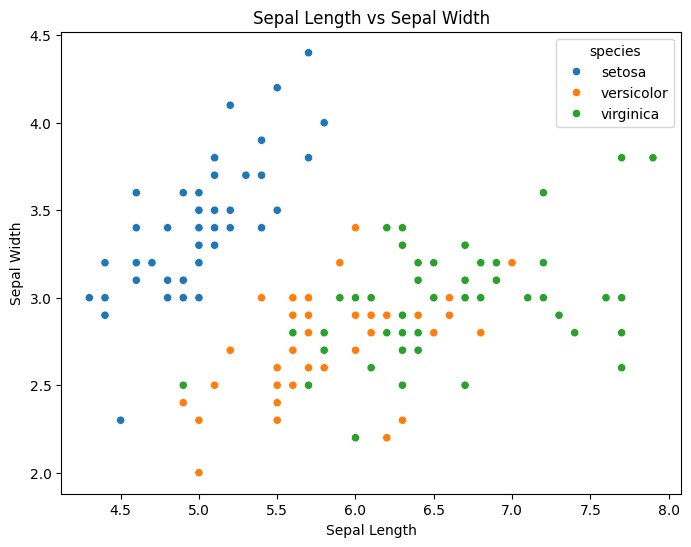

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data = df,
    x = "sepal length (cm)",
    y = "sepal width (cm)",
    hue = "species"
)
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()